In [441]:
# packages
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
# from shapely.geometry import Point
import contextily as ctx
import numpy as np

In [442]:
crash_df = pd.read_csv("crash_df.csv")

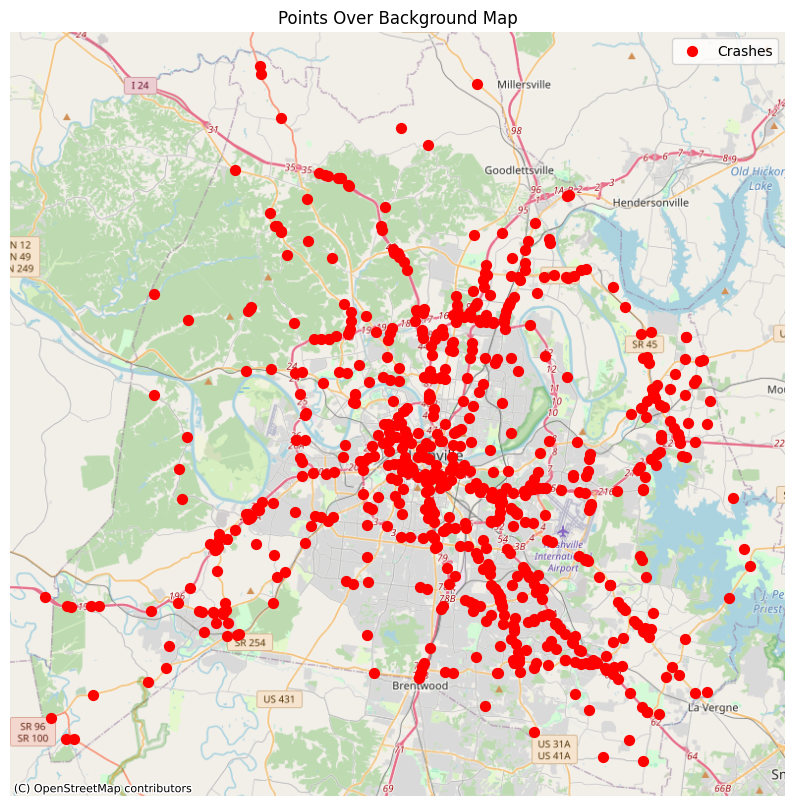

In [443]:
gdf = gpd.GeoDataFrame(
    crash_df,
    geometry=gpd.points_from_xy(crash_df.LONGITUD, crash_df.LATITUDE),
    crs="EPSG:4326")

gdf_web_mercator = gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 10))

gdf_web_mercator.plot(ax=ax, marker='o', color='red', markersize=50, label='Crashes')

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.title("Points Over Background Map")
plt.legend()
plt.show()

In [444]:
from shapely.geometry import Point

# load precinct map
precincts_map = gpd.read_file('precinct_zip.zip')


geometry = [Point(xy) for xy in zip(crash_df['LONGITUD'], crash_df['LATITUDE'])]
crashes_gdf = gpd.GeoDataFrame(crash_df, geometry=geometry)

# epsg=4326 reads lat-lon
crashes_gdf.set_crs(epsg=4326, inplace=True)
precincts_map = precincts_map.to_crs(epsg=4326)

# perform spatial join on shape data and crash data
precinct_df = gpd.sjoin(crashes_gdf, precincts_map, how='left', predicate='within')


In [445]:
precinct_df.head()

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,PrecinctNa,GLOBALID
0,6,1760,0000000,0,36.177206,1,8,35,0,99,...,1,0,99,-86.753983,2,17,POINT (-86.75398 36.17721),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
1,2,1760,0000000,0,36.216794,2,8,30,0,99,...,1,0,99,-86.728900,5,17,POINT (-86.7289 36.21679),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
2,4,1760,0000000,0,36.196736,1,53,40,0,99,...,1,0,99,-86.828469,14,8,POINT (-86.82847 36.19674),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
3,7,1760,0000000,0,36.165511,1,42,0,0,99,...,1,0,99,-86.733536,14,3,POINT (-86.73354 36.16551),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
4,2,1760,0000000,0,36.057653,2,53,40,0,88,...,1,0,99,-86.691097,26,22,POINT (-86.6911 36.05765),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce


In [446]:
precinct_df = precinct_df.rename(columns = {"PrecinctNa": "precinct"})

In [447]:
precinct_df[precinct_df['precinct'].isna()]

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,precinct,GLOBALID
147,5,1760,0000000,7,36.082542,2,12,20,0,99,...,3,1,99,-87.044678,27,17,POINT (-87.04468 36.08254),NaN,NaN,NaN


The only na value from spatial join was this one point that falls just out the modern boundary for Nashville

In [448]:
precinct_df = precinct_df.dropna(subset=['precinct'])
precinct_df

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,precinct,GLOBALID
0,6,1760,0000000,0,36.177206,1,8,35,0,99,...,1,0,99,-86.753983,2,17,POINT (-86.75398 36.17721),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
1,2,1760,0000000,0,36.216794,2,8,30,0,99,...,1,0,99,-86.728900,5,17,POINT (-86.7289 36.21679),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
2,4,1760,0000000,0,36.196736,1,53,40,0,99,...,1,0,99,-86.828469,14,8,POINT (-86.82847 36.19674),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
3,7,1760,0000000,0,36.165511,1,42,0,0,99,...,1,0,99,-86.733536,14,3,POINT (-86.73354 36.16551),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
4,2,1760,0000000,0,36.057653,2,53,40,0,88,...,1,0,99,-86.691097,26,22,POINT (-86.6911 36.05765),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,7,1760,0000000,0,36.139911,5,24,11,0,8,...,1,1,33,-86.727811,28,8,POINT (-86.72781 36.13991),7.0,HERMITAGE,3c8dbffb-01f5-4852-94d8-efcfb93b8f11
703,1,1760,0000000,6,36.151800,2,12,3,0,11,...,2,1,16,-86.771250,29,10,POINT (-86.77125 36.1518),8.0,CENTRAL,bd3522ab-ee43-4c13-81a4-20b6081156be
704,7,1760,0000000,0,36.049039,10,8,24,0,14,...,1,1,46,-86.652550,21,13,POINT (-86.65255 36.04904),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce
705,6,1760,0000000,6,36.184889,1,12,10,0,17,...,2,1,17,-86.773681,27,17,POINT (-86.77368 36.18489),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc


In [449]:
precinct_df[precinct_df['HOUR']==max(precinct_df['HOUR'])]

,DAY_WEEK,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,geometry,index_right,precinct,GLOBALID
182,6,1760,0000000,0,36.194222,99,24,99,0,99,...,1,1,99,-86.776294,23,99,POINT (-86.77629 36.19422),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
246,4,1760,0000000,0,36.174844,1,5,99,0,88,...,1,0,99,-86.719419,20,99,POINT (-86.71942 36.17484),0.0,EAST,6061003e-0f50-499e-9284-544cc171dabc
303,6,1760,0000000,0,36.138800,1,1,99,0,88,...,1,0,99,-86.811800,31,99,POINT (-86.8118 36.1388),5.0,MIDTOWN HILLS,517c3325-2df7-4dfa-b41b-b57269031e66
316,5,1760,0000000,0,36.130589,1,58,99,0,88,...,1,0,99,-86.869981,17,99,POINT (-86.86998 36.13059),3.0,WEST,5f877b5b-5249-4235-ae9d-28820dbd2afb
363,3,1760,0000000,0,36.283569,1,42,99,0,88,...,1,0,99,-86.861169,24,99,POINT (-86.86117 36.28357),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3
373,2,1760,0000000,0,36.190011,1,1,99,0,88,...,1,0,99,-86.612031,15,99,POINT (-86.61203 36.19001),7.0,HERMITAGE,3c8dbffb-01f5-4852-94d8-efcfb93b8f11
384,7,1760,0000000,0,36.103269,1,8,99,0,88,...,1,0,99,-86.627519,15,99,POINT (-86.62752 36.10327),7.0,HERMITAGE,3c8dbffb-01f5-4852-94d8-efcfb93b8f11
390,4,1760,0000000,0,36.150039,10,33,99,0,99,...,1,0,99,-86.675931,30,99,POINT (-86.67593 36.15004),7.0,HERMITAGE,3c8dbffb-01f5-4852-94d8-efcfb93b8f11
423,1,1760,0000000,6,36.079489,2,12,99,0,99,...,2,1,99,-86.644600,20,99,POINT (-86.6446 36.07949),4.0,SOUTHEAST,29f1598c-0572-465e-9245-610f6f4da1ce
455,1,1760,0000000,0,36.208850,99,38,99,0,88,...,1,0,30,-86.833511,4,99,POINT (-86.83351 36.20885),2.0,NORTH,fc925a5e-2a0b-4b5e-a3f5-25d3c38034f3


In [450]:
# FARS dataset usually records unknown hours as 99, so we filter those out
precinct_df = precinct_df[precinct_df['HOUR'] < 24]

# FARS DAY_WEEK usually maps 1=Sunday, 2=Monday, ..., 7=Saturday
# We can map it to match the 0-6 (Mon-Sun) 
day_map = {2: 0, 3: 1, 4: 2, 5: 3, 6: 4, 7: 5, 1: 6}
precinct_df['WEEK_DAY'] = precinct_df['DAY_WEEK'].map(day_map)

c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [451]:
precinct_df = precinct_df.drop(columns={"DAY_WEEK", "geometry", "index_right", "GLOBALID"})
precinct_df

,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,WEATHER,...,SP_JUR,HOSP_MN,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,precinct,WEEK_DAY
0,1760,0000000,0,36.177206,1,8,35,0,99,1,...,0,99,1,0,99,-86.753983,2,17,EAST,4
1,1760,0000000,0,36.216794,2,8,30,0,99,2,...,0,99,1,0,99,-86.728900,5,17,EAST,0
2,1760,0000000,0,36.196736,1,53,40,0,99,1,...,0,99,1,0,99,-86.828469,14,8,NORTH,2
3,1760,0000000,0,36.165511,1,42,0,0,99,1,...,0,99,1,0,99,-86.733536,14,3,EAST,5
4,1760,0000000,0,36.057653,2,53,40,0,88,2,...,0,88,1,0,99,-86.691097,26,22,SOUTHEAST,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
702,1760,0000000,0,36.139911,5,24,11,0,8,5,...,0,59,1,1,33,-86.727811,28,8,HERMITAGE,5
703,1760,0000000,6,36.151800,2,12,3,0,11,2,...,0,0,2,1,16,-86.771250,29,10,CENTRAL,6
704,1760,0000000,0,36.049039,10,8,24,0,14,10,...,0,20,1,1,46,-86.652550,21,13,SOUTHEAST,5
705,1760,0000000,6,36.184889,1,12,10,0,17,1,...,0,36,2,1,17,-86.773681,27,17,EAST,4


In [452]:
# Create the inclusive mapping
segment_map = {
    0: 'Late Night', 1: 'Late Night', 2: 'Late Night', 3: 'Late Night',
    4: 'Early Morning', 5: 'Early Morning', 6: 'Early Morning', 7: 'Early Morning',
    8: 'Morning', 9: 'Morning', 10: 'Morning', 11: 'Morning',
    12: 'Afternoon', 13: 'Afternoon', 14: 'Afternoon', 15: 'Afternoon',
    16: 'Evening', 17: 'Evening', 18: 'Evening', 19: 'Evening',
    20: 'Night', 21: 'Night', 22: 'Night', 23: 'Night'
}

# Apply to the dataframe
precinct_df['time_segment'] = precinct_df['HOUR'].map(segment_map)

In [453]:
precinct_df[["HOUR", "time_segment"]]


,HOUR,time_segment
0,17,Evening
1,17,Evening
2,8,Morning
3,3,Late Night
4,22,Night
...,...,...
702,8,Morning
703,10,Morning
704,13,Afternoon
705,17,Evening


In [454]:
# add back date column for zero-inflation

precinct_df['DATE'] = pd.to_datetime(precinct_df[['YEAR', 'MONTH', 'DAY']])
precinct_df.head()

,CITY,RAIL,MAN_COLL,LATITUDE,WEATHER1,HARM_EV,MINUTE,WEATHER2,HOSP_HR,WEATHER,...,VE_FORMS,NHS,ARR_MIN,LONGITUD,DAY,HOUR,precinct,WEEK_DAY,time_segment,DATE
0,1760,0000000,0,36.177206,1,8,35,0,99,1,...,1,0,99,-86.753983,2,17,EAST,4,Evening,2009-01-02
1,1760,0000000,0,36.216794,2,8,30,0,99,2,...,1,0,99,-86.728900,5,17,EAST,0,Evening,2009-01-05
2,1760,0000000,0,36.196736,1,53,40,0,99,1,...,1,0,99,-86.828469,14,8,NORTH,2,Morning,2009-01-14
3,1760,0000000,0,36.165511,1,42,0,0,99,1,...,1,0,99,-86.733536,14,3,EAST,5,Late Night,2009-02-14
4,1760,0000000,0,36.057653,2,53,40,0,88,2,...,1,0,99,-86.691097,26,22,SOUTHEAST,0,Night,2009-01-26


In [455]:
import itertools
# Generate all dates between 2009 to 2019
all_dates = pd.date_range(start='2009-01-01', end='2019-12-31', freq='D')

# time segments and precincts, so each precinct gets 0 values for every time segment at least
segments = ['Late Night', 'Early Morning', 'Morning', 'Afternoon', 'Evening', 'Night']
precincts = precinct_df['precinct'].unique() # e.g., ['CENTRAL', 'WEST', 'SOUTH', etc.]

# Create the cartesian product
master_grid = pd.DataFrame(list(itertools.product(all_dates, segments, precincts)), 
                           columns=['DATE', 'time_segment', 'precinct'])

In [456]:
master_grid['WEEK_DAY'] = master_grid['DATE'].dt.day_name()

In [457]:
precinct_df['FATAL_CRASH'] = 1

# 2. Group your actual data by date, segment, and precinct to handle multiple crashes in one block
crash_counts = precinct_df.groupby(['DATE', 'time_segment', 'precinct'])['FATAL_CRASH'].sum().reset_index()

crash_counts

,DATE,time_segment,precinct,FATAL_CRASH
0,2009-01-02,Evening,EAST,1
1,2009-01-05,Evening,EAST,1
2,2009-01-14,Morning,NORTH,1
3,2009-01-24,Late Night,CENTRAL,1
4,2009-01-26,Night,SOUTHEAST,1
...,...,...,...,...
683,2019-12-21,Afternoon,SOUTHEAST,1
684,2019-12-26,Afternoon,NORTH,1
685,2019-12-27,Evening,EAST,1
686,2019-12-28,Morning,HERMITAGE,1


In [458]:
# left join master grid w crash df
inflated_df = pd.merge(master_grid, crash_counts, on=['DATE', 'time_segment', 'precinct'], how='left')

# fill gaps w 0
inflated_df['FATAL_CRASH'] = inflated_df['FATAL_CRASH'].fillna(0)

In [459]:
inflated_df[inflated_df['FATAL_CRASH']>1]

,DATE,time_segment,precinct,WEEK_DAY,FATAL_CRASH
182459,2018-04-02,Night,SOUTHEAST,Monday,2.0


In [460]:
# change singular case of 2 crashes to binary outcome
inflated_df['FATAL_CRASH'] = (inflated_df['FATAL_CRASH'] >= 1).astype(int)

In [461]:
# add back month and year columns
inflated_df['MONTH'] = inflated_df['DATE'].dt.month
inflated_df['YEAR'] = inflated_df['DATE'].dt.year

In [462]:
inflated_df

,DATE,time_segment,precinct,WEEK_DAY,FATAL_CRASH,MONTH,YEAR
0,2009-01-01,Late Night,EAST,Thursday,0,1,2009
1,2009-01-01,Late Night,NORTH,Thursday,0,1,2009
2,2009-01-01,Late Night,SOUTHEAST,Thursday,0,1,2009
3,2009-01-01,Late Night,MIDTOWN HILLS,Thursday,0,1,2009
4,2009-01-01,Late Night,CENTRAL,Thursday,0,1,2009
...,...,...,...,...,...,...,...
216913,2019-12-31,Night,CENTRAL,Tuesday,0,12,2019
216914,2019-12-31,Night,MADISON,Tuesday,0,12,2019
216915,2019-12-31,Night,SOUTH,Tuesday,0,12,2019
216916,2019-12-31,Night,WEST,Tuesday,0,12,2019


In [463]:
inflated_df = inflated_df[(inflated_df['DATE']>= "2010-01-01") &( inflated_df['DATE']<= "2019-03-24")]

In [464]:
sum(inflated_df['FATAL_CRASH'])

549

In [465]:
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 
             7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}


inflated_df['MONTH_NAME'] = inflated_df['MONTH'].map(month_map)


C:\Users\rache\AppData\Local\Temp\ipykernel_18568\2187251782.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  inflated_df['MONTH_NAME'] = inflated_df['MONTH'].map(month_map)


In [466]:
inflated_df

,DATE,time_segment,precinct,WEEK_DAY,FATAL_CRASH,MONTH,YEAR,MONTH_NAME
19710,2010-01-01,Late Night,EAST,Friday,0,1,2010,Jan
19711,2010-01-01,Late Night,NORTH,Friday,0,1,2010,Jan
19712,2010-01-01,Late Night,SOUTHEAST,Friday,0,1,2010,Jan
19713,2010-01-01,Late Night,MIDTOWN HILLS,Friday,0,1,2010,Jan
19714,2010-01-01,Late Night,CENTRAL,Friday,0,1,2010,Jan
...,...,...,...,...,...,...,...,...
201685,2019-03-24,Night,CENTRAL,Sunday,0,3,2019,Mar
201686,2019-03-24,Night,MADISON,Sunday,0,3,2019,Mar
201687,2019-03-24,Night,SOUTH,Sunday,0,3,2019,Mar
201688,2019-03-24,Night,WEST,Sunday,0,3,2019,Mar


In [467]:
inflated_df.to_csv("midterm_crash_df.csv")

In [431]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Create the dummy variables
# We drop the first category of each to create our baselines
X = pd.get_dummies(inflated_df[['WEEK_DAY', 'time_segment', 'MONTH', "YEAR"]], drop_first=True)


# 3. Define your target (The '1' or '0' we talked about)
y = inflated_df['FATAL_CRASH']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42)
model_crash = LogisticRegression(max_iter=1000)
model_crash.fit(X_train_c, y_train_c)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [432]:

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_crash.coef_[0],
    'Odds_Ratio': np.exp(model_crash.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
12          time_segment_Night     0.381516    1.464503
3            WEEK_DAY_Saturday     0.354529    1.425509
9         time_segment_Evening     0.264940    1.303352
4              WEEK_DAY_Sunday     0.205143    1.227701
10     time_segment_Late Night     0.086507    1.090359
0                        MONTH     0.033365    1.033928
1                         YEAR    -0.003046    0.996959
6             WEEK_DAY_Tuesday    -0.073933    0.928734
2              WEEK_DAY_Monday    -0.084784    0.918710
5            WEEK_DAY_Thursday    -0.129848    0.878228
7           WEEK_DAY_Wednesday    -0.166484    0.846636
8   time_segment_Early Morning    -0.345557    0.707826
11        time_segment_Morning    -0.383506    0.681468


In [433]:
y_pred = model_crash.predict(X_test_c)
print(classification_report(y_test_c, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     33240
           1       0.00      0.00      0.00       111

    accuracy                           1.00     33351
   macro avg       0.50      0.50      0.50     33351
weighted avg       0.99      1.00      1.00     33351



c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

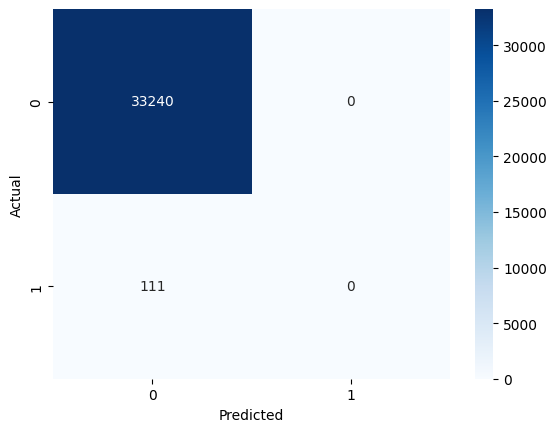

In [434]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the matrix
cm = confusion_matrix(y_test_c, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [435]:
# Stratify split


# Create the dummy variables
# We drop the first category of each to create our baselines
X = pd.get_dummies(inflated_df[['WEEK_DAY', 'time_segment', 'MONTH', "YEAR"]], drop_first=True)


# 3. Define your target (The '1' or '0' we talked about)
y = inflated_df['FATAL_CRASH']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
model_crash = LogisticRegression(max_iter=1000)
model_crash.fit(X_train_c, y_train_c)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [436]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_crash.coef_[0],
    'Odds_Ratio': np.exp(model_crash.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)

                       Feature  Coefficient  Odds_Ratio
12          time_segment_Night     0.377415    1.458510
3            WEEK_DAY_Saturday     0.359802    1.433046
9         time_segment_Evening     0.307557    1.360099
4              WEEK_DAY_Sunday     0.139101    1.149241
10     time_segment_Late Night     0.079312    1.082543
0                        MONTH     0.030441    1.030909
1                         YEAR    -0.003018    0.996986
5            WEEK_DAY_Thursday    -0.089518    0.914372
2              WEEK_DAY_Monday    -0.115850    0.890609
7           WEEK_DAY_Wednesday    -0.116029    0.890449
6             WEEK_DAY_Tuesday    -0.213647    0.807634
11        time_segment_Morning    -0.329474    0.719302
8   time_segment_Early Morning    -0.353174    0.702455


In [437]:
y_pred = model_crash.predict(X_test_c)
print(classification_report(y_test_c, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     83127
           1       0.00      0.00      0.00       249

    accuracy                           1.00     83376
   macro avg       0.50      0.50      0.50     83376
weighted avg       0.99      1.00      1.00     83376



c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\rache\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

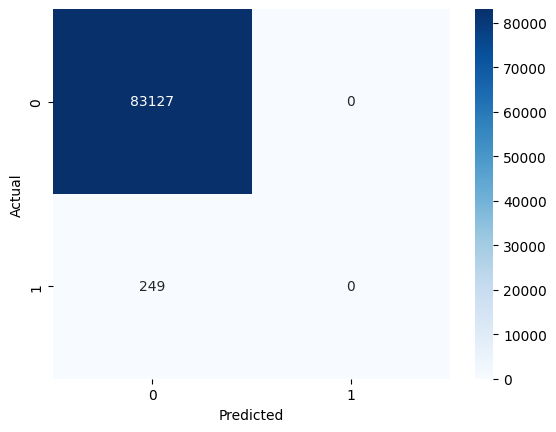

In [438]:

# Generate the matrix
cm = confusion_matrix(y_test_c, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [439]:
sum(y_test_c)

249

                       Feature  Coefficient  Odds_Ratio
20              MONTH_NAME_Oct     0.627162    1.872289
18              MONTH_NAME_May     0.566188    1.761539
19              MONTH_NAME_Nov     0.546031    1.726387
11              MONTH_NAME_Aug     0.526582    1.693136
16              MONTH_NAME_Jun     0.496499    1.642959
14              MONTH_NAME_Jan     0.460568    1.584974
12              MONTH_NAME_Dec     0.421666    1.524500
21              MONTH_NAME_Sep     0.394447    1.483563
10          time_segment_Night     0.343900    1.410437
15              MONTH_NAME_Jul     0.250803    1.285056
17              MONTH_NAME_Mar     0.239282    1.270337
1            WEEK_DAY_Saturday     0.192975    1.212853
7         time_segment_Evening     0.109367    1.115572
2              WEEK_DAY_Sunday     0.092336    1.096733
13              MONTH_NAME_Feb     0.057078    1.058739
8      time_segment_Late Night     0.011838    1.011908
22                   YEAR_2011     0.008480    1

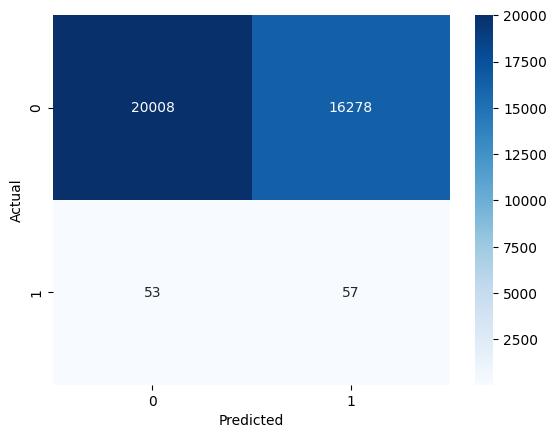

In [469]:
# ONLY TEMPORAL

# Create the dummy variables
# We drop the first category of each to create our baselines
X = pd.get_dummies(inflated_df[['WEEK_DAY', 'time_segment', 'MONTH_NAME', "YEAR"]].astype(str), drop_first=True)


# Define  target 
y = inflated_df['FATAL_CRASH']

# stratify split for test and train data to ensure ratio of crashes to no crashes is the same in both
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) 

# balanced class weights needed for the model, gives more weight to fatal crashes because there's hardly any in the test/train data in comparison to no crash. 
# without this, the model shows 100% accuracy even just guessing 0 every time because only 200 wrong/83127 right 
model_crash = LogisticRegression(class_weight = "balanced", max_iter=1000) 

model_crash.fit(X_train_c, y_train_c)
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_crash.coef_[0],
    'Odds_Ratio': np.exp(model_crash.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)
y_pred = model_crash.predict(X_test_c)
print(classification_report(y_test_c, y_pred))

# Generate the matrix
cm = confusion_matrix(y_test_c, y_pred)

# Visualize it
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [490]:
# Check which Precinct is in the middle of the pack for total fatals
print(precinct_df.groupby('WEEK_DAY').size().sort_values())

# Check which Month is in the middle
print(crash_df.groupby('YEAR').size().sort_values())

WEEK_DAY
2     83
1     86
3     91
0     97
4     98
6    116
5    118
dtype: int64
YEAR
2014    51
2012    54
2013    60
2009    60
2015    62
2010    62
2016    64
2011    66
2017    67
2018    68
2019    93
dtype: int64


### LOGISTIC MODEL WITH PRECINCT

                       Feature  Coefficient  Odds_Ratio
10          time_segment_Night     0.864997    2.374999
8         time_segment_Evening     0.616319    1.852097
6       time_segment_Afternoon     0.489169    1.630960
9      time_segment_Late Night     0.477232    1.611607
36              precinct_NORTH     0.384186    1.468418
2            WEEK_DAY_Saturday     0.364907    1.440380
33          precinct_HERMITAGE     0.358377    1.431005
3              WEEK_DAY_Sunday     0.286665    1.331978
37              precinct_SOUTH     0.249199    1.282998
0              WEEK_DAY_Friday     0.186940    1.205555
1              WEEK_DAY_Monday     0.175709    1.192091
20              MONTH_NAME_Oct     0.151117    1.163133
35      precinct_MIDTOWN HILLS     0.084933    1.088644
38               precinct_WEST     0.083118    1.086670
24                   YEAR_2013     0.047936    1.049103
28                   YEAR_2017     0.031861    1.032374
22                   YEAR_2011     0.023639    1

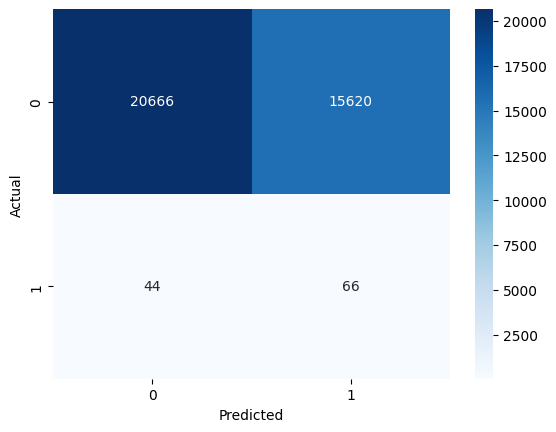

In [ ]:
# WITH PRECINCT

# Create the dummy variables

## NEW DUMMY VARIABLES METHOD TO DROP BASELINE MANUALLY###########
X = pd.get_dummies(inflated_df[['WEEK_DAY', 'time_segment', 'MONTH_NAME', "YEAR", "precinct"]].astype(str))

# manually drop "average" columns
cols_to_drop = [
    'precinct_SOUTHEAST',      
    'WEEK_DAY_Tuesday',          
    'time_segment_Morning',
    'MONTH_NAME_Jan',
    'YEAR_2010'
]

X = X.drop(columns=cols_to_drop)

#########################################

y = inflated_df['FATAL_CRASH']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
model_crash = LogisticRegression(class_weight = "balanced", max_iter=1000)
model_crash.fit(X_train_c, y_train_c)

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model_crash.coef_[0],
    'Odds_Ratio': np.exp(model_crash.coef_[0]) # Essential for interpretation
}).sort_values(by='Coefficient', ascending=False)

print(feature_importance)
y_pred = model_crash.predict(X_test_c)
print(classification_report(y_test_c, y_pred))

cm = confusion_matrix(y_test_c, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [493]:
print(classification_report(y_test_c, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.57      0.73     36286
           1       0.00      0.60      0.01       110

    accuracy                           0.57     36396
   macro avg       0.50      0.58      0.37     36396
weighted avg       0.99      0.57      0.72     36396



In [494]:
from sklearn.metrics import roc_auc_score, roc_curve
y_probs = model_crash.predict_proba(X_test_c)[:,1]
auc_score = roc_auc_score(y_test_c, y_probs)

print(f"ROC-AUC Score: {auc_score:.4f}")

ROC-AUC Score: 0.6133


### MAKE GRAPH OF ODDS RATIOS

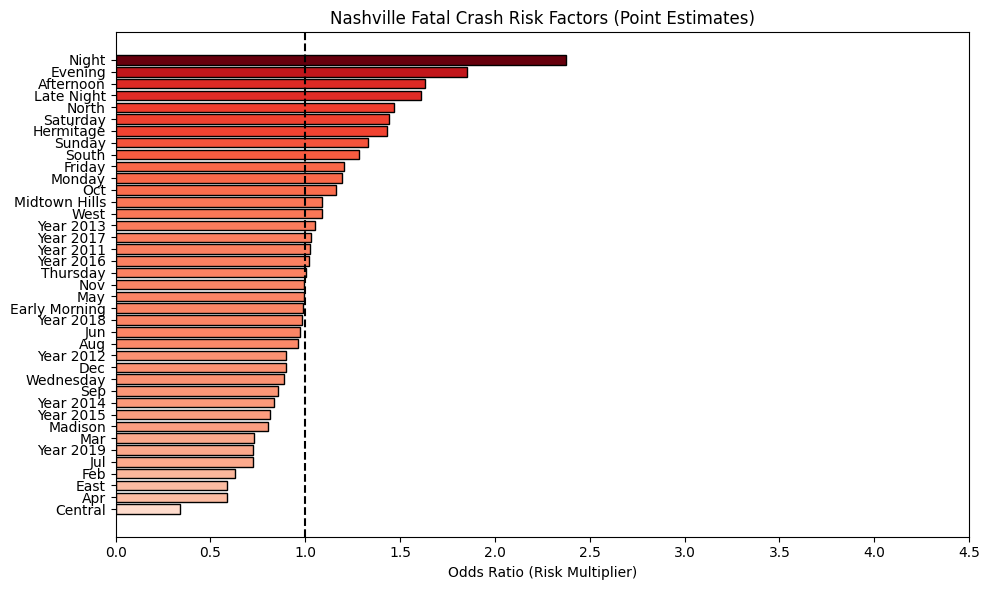

In [503]:

plt.figure(figsize=(10,6))

feature_importance = feature_importance.sort_values("Odds_Ratio")
feature_importance['Display_Name'] = (feature_importance['Feature']
                             .str.replace('precinct_', '', case=False)
                             .str.replace('WEEK_DAY_', '', case=False)
                             .str.replace('MONTH_NAME_', '', case=False)
                             .str.replace('time_segment_', '', case=False)
                             .str.replace('_', ' ')
                             .str.title())
# Using a color map to emphasize the high-risk zones
colors = plt.cm.Reds(feature_importance['Odds_Ratio'] / feature_importance['Odds_Ratio'].max())

plt.barh(feature_importance['Display_Name'], feature_importance['Odds_Ratio'], color=colors, edgecolor='black')
plt.axvline(x=1, color='black', linestyle='--', label='Baseline (No Effect)')

# Annotate the actual OR values on the bars
# for i, v in enumerate(feature_importance['Odds_Ratio']):
#     plt.text(v + 0.15, i, str(v), va='center')

plt.xlabel('Odds Ratio (Risk Multiplier)')
plt.title('Nashville Fatal Crash Risk Factors (Point Estimates)')
plt.xlim(0, 4.5)
plt.tight_layout()
plt.show()